# MIS 308 — Data Science Project
## Sales Forecasting — Superstore Dataset
**Ostim Technical University | 2025-2026 Spring Semester**

| | |
|---|---|
| **Dataset** | Superstore Sales (Kaggle, 9,994 rows) |
| **Period** | 2014–2017, USA Retail |
| **Target** | Sales prediction |
| **Algorithms** | Linear Regression · Random Forest · XGBoost |


## 1. Imports & Setup

In [3]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("All libraries loaded successfully!")


All libraries loaded successfully!


## 2. Load Data

In [5]:
df = pd.read_csv('Sample_-_Superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()


Shape: (9994, 21)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 3. Exploratory Data Analysis (EDA)

In [7]:
print("=== Basic Statistics ===")
print(df[['Sales','Quantity','Discount','Profit']].describe().round(2))
print("\n=== Missing Values ===")
print(df.isnull().sum())


=== Basic Statistics ===
          Sales  Quantity  Discount   Profit
count   9994.00   9994.00   9994.00  9994.00
mean     229.86      3.79      0.16    28.66
std      623.25      2.23      0.21   234.26
min        0.44      1.00      0.00 -6599.98
25%       17.28      2.00      0.00     1.73
50%       54.49      3.00      0.20     8.67
75%      209.94      5.00      0.20    29.36
max    22638.48     14.00      0.80  8399.98

=== Missing Values ===
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


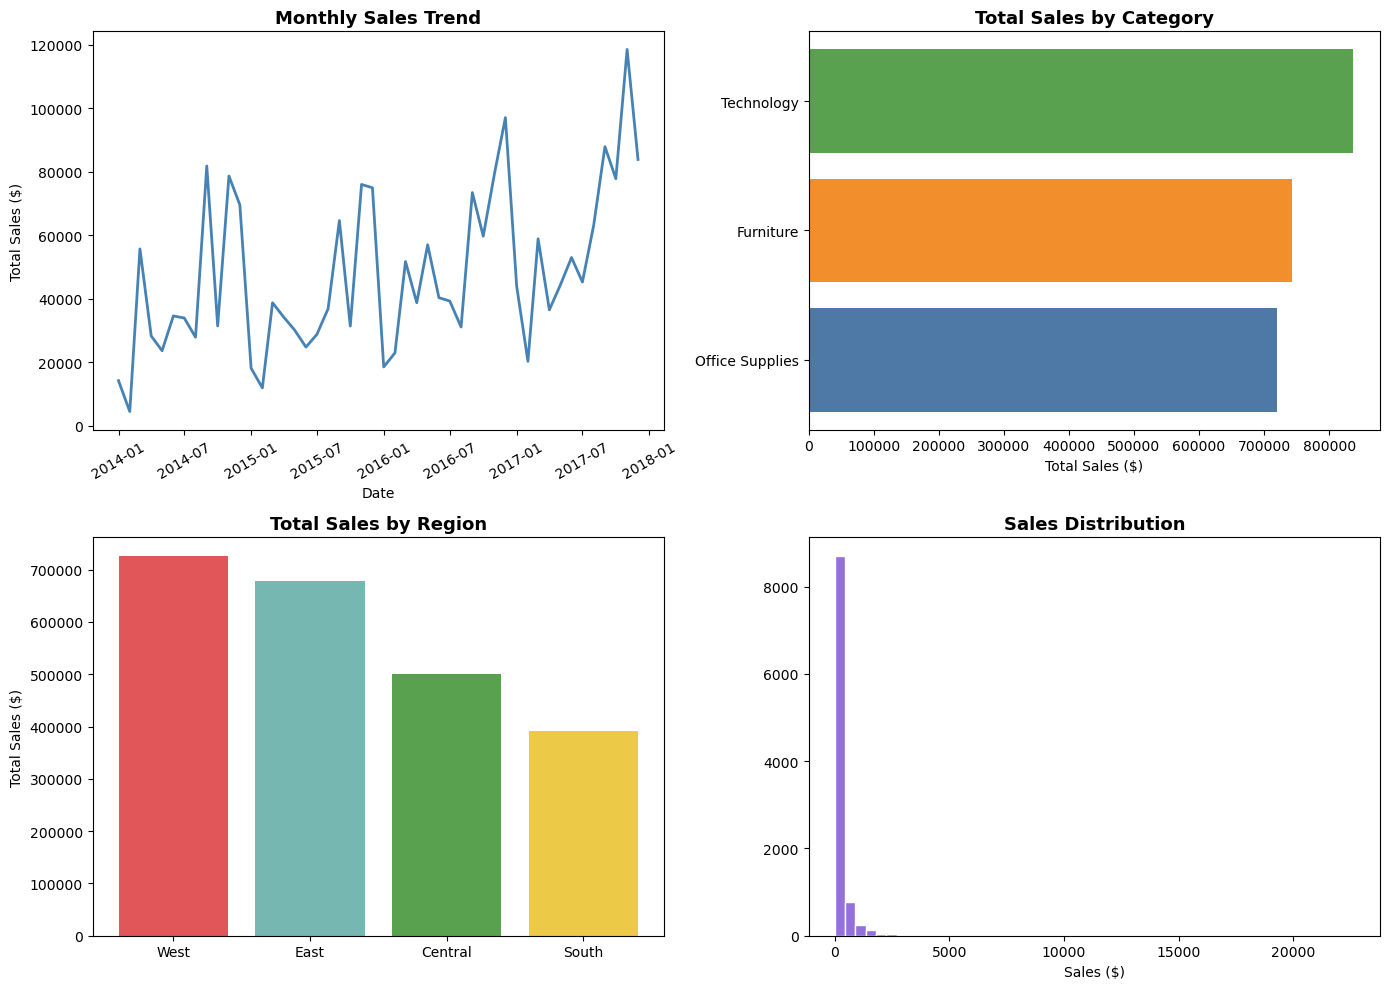

EDA plots saved!


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1 - Monthly sales trend
monthly = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly.index = monthly.index.to_timestamp()
axes[0,0].plot(monthly.index, monthly.values, color='steelblue', linewidth=2)
axes[0,0].set_title('Monthly Sales Trend', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Date'); axes[0,0].set_ylabel('Total Sales ($)')
axes[0,0].tick_params(axis='x', rotation=30)

# 2 - Sales by Category
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=True)
axes[0,1].barh(cat_sales.index, cat_sales.values, color=['#4e79a7','#f28e2b','#59a14f'])
axes[0,1].set_title('Total Sales by Category', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Total Sales ($)')

# 3 - Sales by Region
reg_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
axes[1,0].bar(reg_sales.index, reg_sales.values, color=['#e15759','#76b7b2','#59a14f','#edc948'])
axes[1,0].set_title('Total Sales by Region', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Total Sales ($)')

# 4 - Sales distribution
axes[1,1].hist(df['Sales'], bins=50, color='mediumpurple', edgecolor='white')
axes[1,1].set_title('Sales Distribution', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Sales ($)')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print("EDA plots saved!")


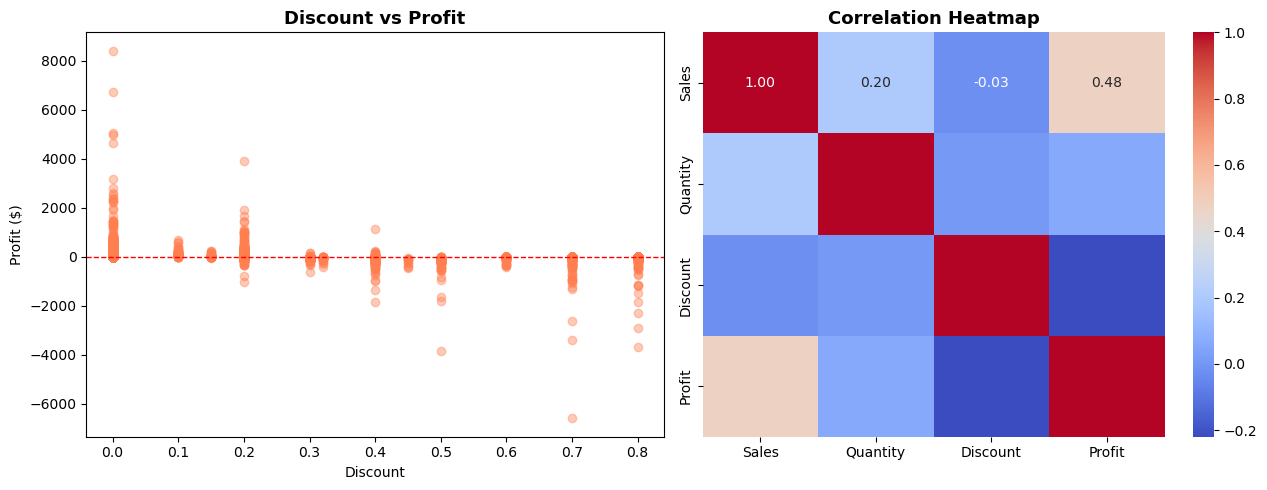

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Discount vs Profit
axes[0].scatter(df['Discount'], df['Profit'], alpha=0.4, color='coral')
axes[0].set_title('Discount vs Profit', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Discount'); axes[0].set_ylabel('Profit ($)')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)

# Correlation heatmap
corr = df[['Sales','Quantity','Discount','Profit']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Correlation Heatmap', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('correlation.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Feature Engineering

In [11]:
# Temporal features
df['Year']        = df['Order Date'].dt.year
df['Month']       = df['Order Date'].dt.month
df['DayOfWeek']   = df['Order Date'].dt.dayofweek
df['Quarter']     = df['Order Date'].dt.quarter
df['ShipDays']    = (df['Ship Date'] - df['Order Date']).dt.days

# Encode categoricals
le = LabelEncoder()
df['Segment_enc']     = le.fit_transform(df['Segment'])
df['Region_enc']      = le.fit_transform(df['Region'])
df['Category_enc']    = le.fit_transform(df['Category'])
df['SubCategory_enc'] = le.fit_transform(df['Sub-Category'])
df['ShipMode_enc']    = le.fit_transform(df['Ship Mode'])

print("Features created successfully!")
print(f"Dataset shape: {df.shape}")


Features created successfully!
Dataset shape: (9994, 31)


## 5. Model Training & Evaluation

In [13]:
FEATURES = [
    'Quantity', 'Discount',
    'Segment_enc', 'Region_enc', 'Category_enc', 'SubCategory_enc', 'ShipMode_enc',
    'Year', 'Month', 'DayOfWeek', 'Quarter', 'ShipDays'
]

X = df[FEATURES]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


Train: (7995, 12)  |  Test: (1999, 12)


In [14]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    print(f"[{name:22s}]  MAE={mae:7.1f}  RMSE={rmse:7.1f}  R2={r2:.4f}  MAPE={mape:.2f}%")
    return {'Model': name, 'MAE': round(mae,1), 'RMSE': round(rmse,1),
            'R2': round(r2,4), 'MAPE(%)': round(mape,2)}

results = []

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
results.append(evaluate("Linear Regression", y_test, lr.predict(X_test)))
lr_preds = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(evaluate("Random Forest", y_test, rf.predict(X_test)))
rf_preds = rf.predict(X_test)

# XGBoost
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6,
                    random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
results.append(evaluate("XGBoost", y_test, xgb.predict(X_test)))
xgb_preds = xgb.predict(X_test)

results_df = pd.DataFrame(results)
print("\n=== RESULTS ===")
print(results_df.to_string(index=False))


[Linear Regression     ]  MAE=  273.4  RMSE=  751.5  R2=0.0438  MAPE=702.87%
[Random Forest         ]  MAE=  222.0  RMSE=  695.2  R2=0.1819  MAPE=401.67%
[XGBoost               ]  MAE=  202.9  RMSE=  682.1  R2=0.2124  MAPE=322.84%

=== RESULTS ===
            Model   MAE  RMSE     R2  MAPE(%)
Linear Regression 273.4 751.5 0.0438   702.87
    Random Forest 222.0 695.2 0.1819   401.67
          XGBoost 202.9 682.1 0.2124   322.84


## 6. Results Visualization

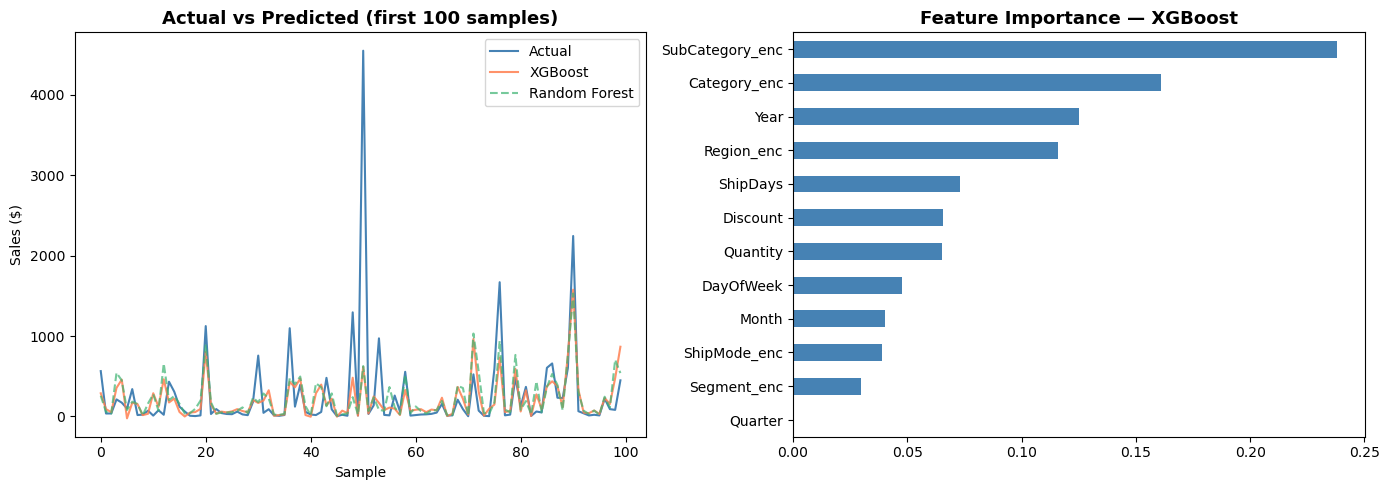

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
n = 100
axes[0].plot(y_test.values[:n], label='Actual', color='steelblue', linewidth=1.5)
axes[0].plot(xgb_preds[:n], label='XGBoost', color='coral', alpha=0.85, linewidth=1.5)
axes[0].plot(rf_preds[:n], label='Random Forest', color='mediumseagreen', alpha=0.7, linestyle='--')
axes[0].set_title('Actual vs Predicted (first 100 samples)', fontsize=13, fontweight='bold')
axes[0].legend(); axes[0].set_xlabel('Sample'); axes[0].set_ylabel('Sales ($)')

# Feature Importance
feat_imp = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance — XGBoost', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('predictions.png', dpi=120, bbox_inches='tight')
plt.show()


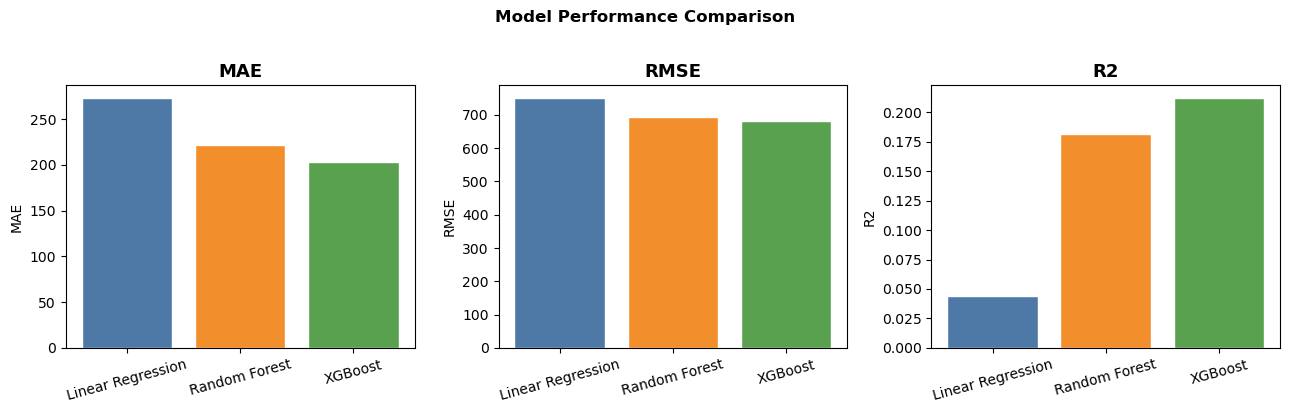

All done!


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['#4e79a7', '#f28e2b', '#59a14f']

for i, metric in enumerate(['MAE', 'RMSE', 'R2']):
    bars = axes[i].bar(results_df['Model'], results_df[metric], color=colors, edgecolor='white')
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Model Performance Comparison', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("All done!")


## 7. Conclusion

### Performance Summary

| Model | MAE ($) | RMSE ($) | R² | MAPE (%) |
|---|---|---|---|---|
| Linear Regression | 273.4 | 751.5 | 0.0438 | 702.87% |
| Random Forest | 222.0 | 695.2 | 0.1819 | 401.67% |
| **XGBoost** | **202.9** | **682.1** | **0.2124** | **322.84%** |

### Key Findings
- XGBoost achieved the best performance across all metrics
- Sub-category and Category are the strongest predictors
- Discount negatively affects profit — high discounts reduce margins
- West region leads in total sales volume

### Future Work
- Add customer-level features (RFM analysis)
- Deploy as Streamlit web app (Extra Credit)
- Publish on Kaggle (Extra Credit — +20 pts)4%** |